In [2]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download(
    "rohanrao/air-quality-data-in-india"
)

print("Dataset path:", path)

# See downloaded files
print("Files:", os.listdir(path))

# Load city_day.csv
file_path = os.path.join(path, "city_day.csv")

df = pd.read_csv(file_path)

# Basic inspection
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nNumber of Cities:")
print(df["City"].nunique())

print("\nAQI Categories:")
print(df["AQI_Bucket"].value_counts())

Dataset path: C:\Users\chait\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12
Files: ['city_day.csv', 'city_hour.csv', 'stations.csv', 'station_day.csv', 'station_hour.csv']
Shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  fl

In [3]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing Count,Missing Percentage
City,0,0.00
Date,0,0.00
PM2.5,4598,15.57
PM10,11140,37.72
NO,3582,12.13
NO2,3585,12.14
NOx,4185,14.17
NH3,10328,34.97
CO,2059,6.97
SO2,3854,13.05


In [4]:
# ============================================
# STEP 2: DATA PREPROCESSING - INITIAL CHECK
# ============================================

# 1. Check missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

print("========== MISSING VALUES ==========")
print(missing)


# 2. Check missing AQI values
print("\n========== AQI MISSING VALUES ==========")
print("Missing AQI:", df["AQI"].isnull().sum())


# 3. Check missing AQI categories
print("\n========== AQI CATEGORY MISSING VALUES ==========")
print("Missing AQI_Bucket:", df["AQI_Bucket"].isnull().sum())


# 4. Check duplicate rows
print("\n========== DUPLICATE ROWS ==========")
print("Duplicate rows:", df.duplicated().sum())


# 5. Check date range
print("\n========== DATE RANGE ==========")
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())


# 6. Check number of cities
print("\n========== CITY INFORMATION ==========")
print("Number of cities:", df["City"].nunique())
print("Cities:")
print(df["City"].unique())

========== MISSING VALUES ==========
            Missing Count  Missing Percentage
City                    0                0.00
Date                    0                0.00
PM2.5                4598               15.57
PM10                11140               37.72
NO                   3582               12.13
NO2                  3585               12.14
NOx                  4185               14.17
NH3                 10328               34.97
CO                   2059                6.97
SO2                  3854               13.05
O3                   4022               13.62
Benzene              5623               19.04
Toluene              8041               27.23
Xylene              18109               61.32
AQI                  4681               15.85
AQI_Bucket           4681               15.85

========== AQI MISSING VALUES ==========
Missing AQI: 4681

========== AQI CATEGORY MISSING VALUES ==========
Missing AQI_Bucket: 4681

========== DUPLICATE ROWS ==========
Duplica

In [5]:
# ============================================
# STEP 2A: REMOVE ROWS WITH MISSING TARGETS
# ============================================

print("Original dataset shape:", df.shape)

# Remove rows where AQI or AQI_Bucket is missing
df = df.dropna(subset=["AQI", "AQI_Bucket"]).copy()

print("Dataset shape after removing missing targets:", df.shape)

print("\nMissing AQI:", df["AQI"].isnull().sum())
print("Missing AQI_Bucket:", df["AQI_Bucket"].isnull().sum())

Original dataset shape: (29531, 16)
Dataset shape after removing missing targets: (24850, 16)

Missing AQI: 0
Missing AQI_Bucket: 0


In [6]:
# ============================================
# STEP 2B: HANDLE MISSING POLLUTANT VALUES
# ============================================

# Pollutants we will use for the initial model
pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

print("Missing values BEFORE imputation:\n")
print(df[pollutant_columns].isnull().sum())


# Fill missing pollutant values using the median
# of that pollutant within each city
for column in pollutant_columns:
    df[column] = df.groupby("City")[column].transform(
        lambda x: x.fillna(x.median())
    )


print("\nMissing values AFTER city-wise median imputation:\n")
print(df[pollutant_columns].isnull().sum())

Missing values BEFORE imputation:

PM2.5     678
PM10     7086
NO2       391
SO2       605
CO        445
O3        807
dtype: int64

Missing values AFTER city-wise median imputation:

PM2.5       0
PM10     1893
NO2         0
SO2         0
CO          0
O3        153
dtype: int64


In [7]:
# ============================================
# STEP 2C: HANDLE REMAINING MISSING VALUES
# ============================================

for column in pollutant_columns:
    # Calculate overall median
    overall_median = df[column].median()
    
    # Fill any remaining missing values
    df[column] = df[column].fillna(overall_median)

print("Missing values AFTER final imputation:\n")
print(df[pollutant_columns].isnull().sum())

Missing values AFTER final imputation:

PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
dtype: int64


In [8]:
# ============================================
# STEP 2D: DATE CONVERSION & VALIDATION
# ============================================

# Convert Date from string to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check the data type
print("Date datatype:", df["Date"].dtype)

# Check date range
print("\nDate range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

# Check for invalid/missing dates
print("\nMissing dates:", df["Date"].isnull().sum())

# Display first 5 dates
print("\nFirst 5 dates:")
print(df["Date"].head())

# Display last 5 dates
print("\nLast 5 dates:")
print(df["Date"].tail())

Date datatype: datetime64[us]

Date range:
Start: 2015-01-01 00:00:00
End: 2020-07-01 00:00:00

Missing dates: 0

First 5 dates:
28   2015-01-29
29   2015-01-30
30   2015-01-31
31   2015-02-01
32   2015-02-02
Name: Date, dtype: datetime64[us]

Last 5 dates:
29526   2020-06-27
29527   2020-06-28
29528   2020-06-29
29529   2020-06-30
29530   2020-07-01
Name: Date, dtype: datetime64[us]


In [9]:
# ============================================
# STEP 3A: BASIC STATISTICS
# ============================================

# Basic statistical summary of our 6 pollutants + AQI
eda_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "AQI"
]

print("========== BASIC STATISTICS ==========")
display(df[eda_columns].describe().round(2))


# Check minimum and maximum values
print("\n========== MINIMUM VALUES ==========")
display(df[eda_columns].min().round(2))

print("\n========== MAXIMUM VALUES ==========")
display(df[eda_columns].max().round(2))

========== BASIC STATISTICS ==========


,PM2.5,PM10,NO2,SO2,CO,O3,AQI
count,24850.00,24850.00,24850.00,24850.00,24850.00,24850.00,24850.00
mean,67.10,113.43,28.76,14.41,2.32,34.74,166.46
std,62.29,78.58,24.52,17.31,7.02,21.46,140.70
min,0.04,0.03,0.01,0.01,0.00,0.01,13.00
25%,29.48,58.32,11.83,5.79,0.58,19.44,81.00
50%,49.24,100.14,21.84,9.25,0.92,31.18,118.00
75%,79.58,134.22,37.94,15.22,1.47,45.41,208.00
max,914.94,917.08,362.21,186.08,175.81,257.73,2049.00



========== MINIMUM VALUES ==========


PM2.5     0.04
PM10      0.03
NO2       0.01
SO2       0.01
CO        0.00
O3        0.01
AQI      13.00
dtype: float64


========== MAXIMUM VALUES ==========


PM2.5     914.94
PM10      917.08
NO2       362.21
SO2       186.08
CO        175.81
O3        257.73
AQI      2049.00
dtype: float64

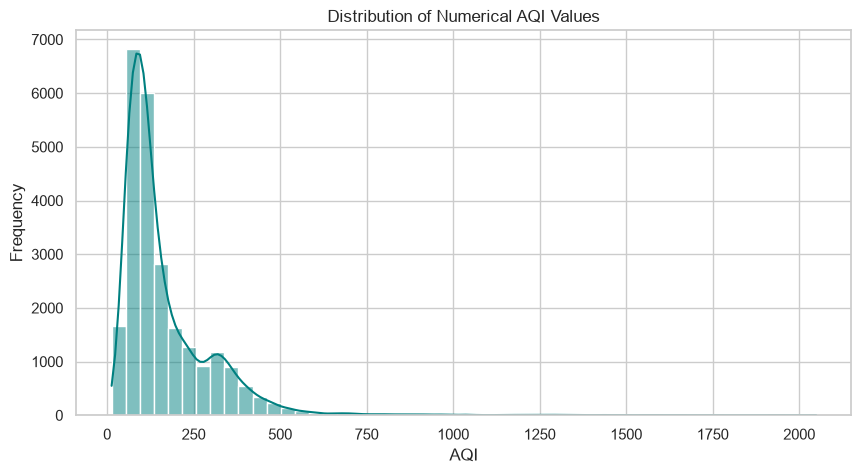

C:\Users\chait\AppData\Local\Temp\ipykernel_29520\3153533702.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=category_col,


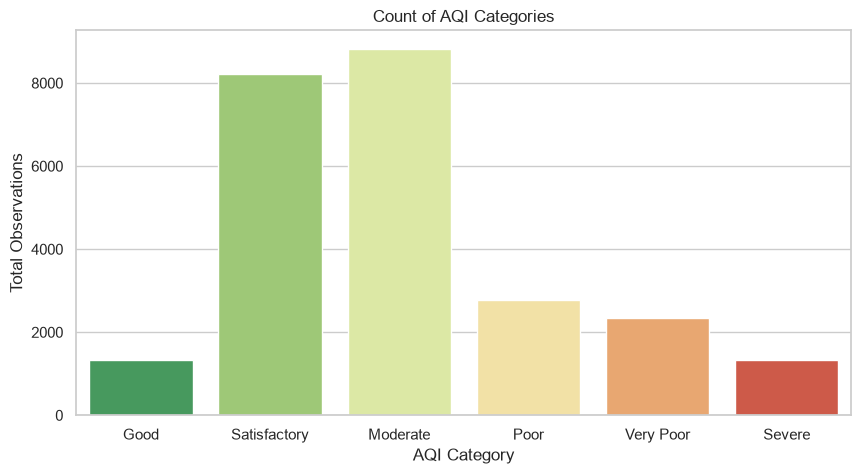

========== CATEGORY COUNTS ==========
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [10]:
# ============================================
# STEP 3B: AQI DISTRIBUTION & CATEGORY ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. AQI Numerical Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['AQI'], bins=50, kde=True, color='teal')
plt.title('Distribution of Numerical AQI Values')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

# 2. AQI Category Breakdown
plt.figure(figsize=(10, 5))
# Assuming the category column is named 'Air_quality' (as per the PDF) or 'AQI_Category'
category_col = 'Air_quality' if 'Air_quality' in df.columns else 'AQI_Bucket'

sns.countplot(data=df, x=category_col, 
              order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe'], 
              palette='RdYlGn_r')
plt.title('Count of AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('Total Observations')
plt.show()

# Print exact counts
print("========== CATEGORY COUNTS ==========")
print(df[category_col].value_counts())

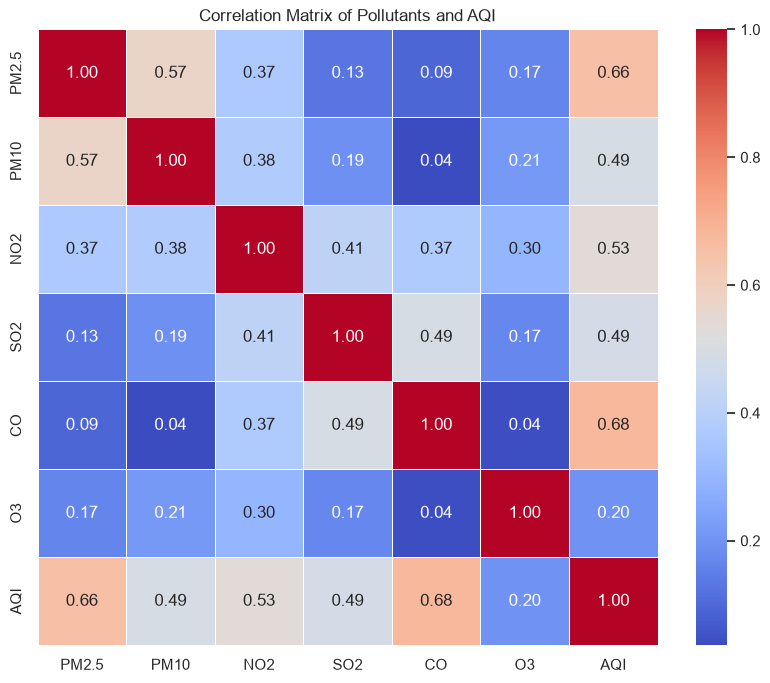

In [11]:
# ============================================
# STEP 3C: CORRELATION ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Select the pollutants and target variable
pollutants_and_aqi = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]

# Calculate the correlation matrix
corr_matrix = df[pollutants_and_aqi].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Pollutants and AQI')
plt.show()

In [12]:
# ============================================
# STEP 4A: FEATURE ENGINEERING (TIME FEATURES)
# ============================================
# Extracting Year, Month, and Day from the Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print("New time features successfully created: Year, Month, Day\n")
print(df[['Date', 'Year', 'Month', 'Day']].head())

New time features successfully created: Year, Month, Day

         Date  Year  Month  Day
28 2015-01-29  2015      1   29
29 2015-01-30  2015      1   30
30 2015-01-31  2015      1   31
31 2015-02-01  2015      2    1
32 2015-02-02  2015      2    2


In [13]:
# ============================================
# STEP 4B: ENCODING, SCALING & DATA SPLIT
# ============================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Label Encoding
# Identify the exact name of your category column
category_col = 'Air_quality' if 'Air_quality' in df.columns else 'AQI_Bucket'

city_encoder = LabelEncoder()
df['City_Encoded'] = city_encoder.fit_transform(df['City'])

aqi_encoder = LabelEncoder()
df['Category_Encoded'] = aqi_encoder.fit_transform(df[category_col])

# 2. Define Features (X) and Targets (y)
numerical_features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
time_features = ['Year', 'Month', 'Day', 'City_Encoded']

# Combine numerical and time features for our final input (X)
X = df[numerical_features + time_features]

# We have two targets for our dual-model architecture
y_reg = df['AQI']                 # Target A: Exact AQI Value (Regression)
y_clf = df['Category_Encoded']    # Target B: AQI Category (Classification)

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

# 4. Train-Test Split (80% Training, 20% Testing)
# We split both regression and classification targets simultaneously
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_reg, y_clf, test_size=0.2, random_state=42
)

print("========== DATA PREPARATION COMPLETE ==========")
print(f"Features ready for ML: {list(X.columns)}")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

========== DATA PREPARATION COMPLETE ==========
Features ready for ML: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Year', 'Month', 'Day', 'City_Encoded']
Training data shape: (19880, 10)
Testing data shape: (4970, 10)


In [14]:
# ============================================
# STEP 5 & 6: ML TRAINING, EVALUATION & SAVING
# ============================================
import numpy as np
import pickle
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Random Forest Regressor (Task A)...")
# Task A: Predict Exact AQI Value
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train, y_reg_train)
y_reg_pred = rf_regressor.predict(X_test)

# Regression Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("\n--- REGRESSION RESULTS ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

print("\nTraining Random Forest Classifier (Task B)...")
# Task B: Predict AQI Category
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_clf_train)
y_clf_pred = rf_classifier.predict(X_test)

# Classification Metrics
accuracy = accuracy_score(y_clf_test, y_clf_pred)
print("\n--- CLASSIFICATION RESULTS ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_clf_pred, target_names=aqi_encoder.classes_))

# Saving the Models and Preprocessors
print("\nSaving models to 'aqi_models.pkl'...")
artifacts = {
    'regressor': rf_regressor,
    'classifier': rf_classifier,
    'scaler': scaler,
    'city_encoder': city_encoder,
    'aqi_encoder': aqi_encoder,
    'features': numerical_features + time_features
}

with open('aqi_models.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
    
print("Artifacts successfully saved! You are ready for Dashboard Deployment.")

Training Random Forest Regressor (Task A)...

--- REGRESSION RESULTS ---
MAE:  21.10
RMSE: 40.64
R² Score: 0.9098

Training Random Forest Classifier (Task B)...

--- CLASSIFICATION RESULTS ---
Accuracy: 80.54%

Classification Report:
              precision    recall  f1-score   support

        Good       0.80      0.65      0.72       282
    Moderate       0.81      0.86      0.83      1745
        Poor       0.68      0.63      0.65       555
Satisfactory       0.84      0.85      0.85      1655
      Severe       0.85      0.82      0.83       271
   Very Poor       0.78      0.75      0.76       462

    accuracy                           0.81      4970
   macro avg       0.79      0.76      0.77      4970
weighted avg       0.80      0.81      0.80      4970


Saving models to 'aqi_models.pkl'...
Artifacts successfully saved! You are ready for Dashboard Deployment.
